# Comparison: Numerov - Whittaker
This notebook compares the Numerov method (with and without model potentials) to the Whittaker method for calculating Rydberg wavefunctions and matrix elements.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from rydstate.angular import AngularKetLS
from rydstate.radial import RadialKet
from rydstate.species import get_potential_class, get_sqdt

## Wavefunction

In [2]:
radial_kets: dict[str, RadialKet] = {}

species, n, l, j = "Rb", 21, 0, 0.5
angular = AngularKetLS(l_r=l, j_tot=j, species=species)

sqdt = get_sqdt(species)
potential_marinescu = get_potential_class(species, "marinescu_1994")
potential_coulomb = get_potential_class(species, "coulomb")
nu = sqdt.calc_nu(n, angular)

radial = RadialKet(nu, potential_marinescu(l), parameters={"integration_method": "numerov"})
radial.integrate_wavefunction()
radial_kets["Numerov with Model Potentials"] = radial

# Using Numerov without model potentials will lead to some warnings,
# since the resulting wavefunction does not pass all heuristic checks
radial_without_mp = RadialKet(nu, potential_coulomb(l), parameters={"integration_method": "numerov"})
radial_without_mp.integrate_wavefunction()
radial_kets["Numerov without Model Potentials"] = radial_without_mp

The wavefunction for the radial_ket RadialKet(nu=17.86825962895559, potential=PotentialCoulombRubidium(l_r=0)) has some issues:
      The wavefunction is not close to zero at the inner boundary (inner_weight_scaled_to_whole_grid=1.16e-04)
      The integration for l=0 did stop at 0.14 (should be close to zero).


In [3]:
radial_whittaker = RadialKet(
    nu,
    potential_coulomb(l),
    parameters={"integration_method": "whittaker", "x_min": radial.x_list[0], "x_max": radial.x_list[-1]},
)
radial_whittaker.integrate_wavefunction()
radial_kets["Whittaker"] = radial_whittaker

Using Whittaker to get the wavefunction is not recommended! Use this only for comparison.


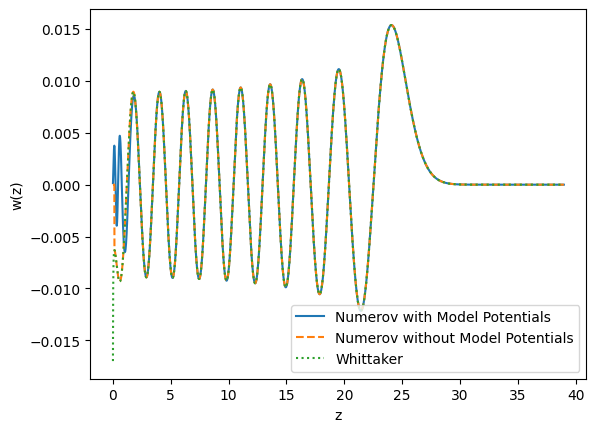

In [4]:
fig, ax = plt.subplots()

styles = ["-", "--", ":"]
for i, (label, radial) in enumerate(radial_kets.items()):
    ax.plot(radial.z_list, radial.w_list, ls=styles[i], label=label)
ax.legend()

ax.set_xlabel("z")
ax.set_ylabel("w(z)")

ax.set_ylim(1.1 * np.min(radial.w_list), 1.1 * np.max(radial.w_list))

plt.show()

## Radial matrix elements

In [5]:
l1, l2 = 0, 1
nu1 = sqdt.calc_nu(10, AngularKetLS(l_r=l1, j_tot=0.5, species=species))
nu2 = sqdt.calc_nu(9, AngularKetLS(l_r=l2, j_tot=1.5, species=species))

radial1 = RadialKet(nu1, potential_marinescu(l1), parameters={"integration_method": "numerov"})
radial2 = RadialKet(nu2, potential_marinescu(l2), parameters={"integration_method": "numerov"})
dipole_me = radial1.calc_matrix_element(radial2, 1)
print(f"Numerov with model potentials: {dipole_me}", flush=True)

radial1 = RadialKet(nu1, potential_coulomb(l1), parameters={"integration_method": "numerov"})
radial2 = RadialKet(nu2, potential_coulomb(l2), parameters={"integration_method": "numerov"})
dipole_me = radial1.calc_matrix_element(radial2, 1)
print(f"Numerov without model potentials: {dipole_me}", flush=True)

radial1 = RadialKet(nu1, potential_coulomb(l1), parameters={"integration_method": "whittaker"})
radial2 = RadialKet(nu2, potential_coulomb(l2), parameters={"integration_method": "whittaker"})
dipole_me = radial1.calc_matrix_element(radial2, 1)
print(f"Whittaker: {dipole_me}", flush=True)

Numerov with model potentials: 43.64042739463943 bohr


The wavefunction for the radial_ket RadialKet(nu=6.864783105371448, potential=PotentialCoulombRubidium(l_r=0)) has some issues:
      The integration for l=0 did stop at 0.14 (should be close to zero).
The wavefunction for the radial_ket RadialKet(nu=6.350837333725099, potential=PotentialCoulombRubidium(l_r=1)) has some issues:
      The wavefunction is not close to zero at the inner boundary (inner_weight_scaled_to_whole_grid=3.52e-02)


Numerov without model potentials: 43.60588874251337 bohr


Using Whittaker to get the wavefunction is not recommended! Use this only for comparison.
Using Whittaker to get the wavefunction is not recommended! Use this only for comparison.


Whittaker: 43.561313364176684 bohr
